#Data Visualization on Python

##Roberto Castro Molinares

##Problem 1

Copy the code below into your code. Run the code. It should download and open a new dataset that has CO2 emissions for a field site in Barrow, Alaska (brw).

Dataset: Atmospheric Carbon Dioxide Dry Air Mole Fractions from continuous measurements at Mauna Loa, Hawaii, Barrow, Alaska, American Samoa and South Pole, 1973-present.

Citation: Thoning, K.W., A.M. Crotwell, and J.W. Mund (2025). Version 2025-04-26

Data successfully loaded. Shape: (616, 19)
   year month   value
1  1973     8  322.73
2  1973     9  324.79
3  1973    10  329.86
4  1973    11  333.61
5  1973    12  334.60


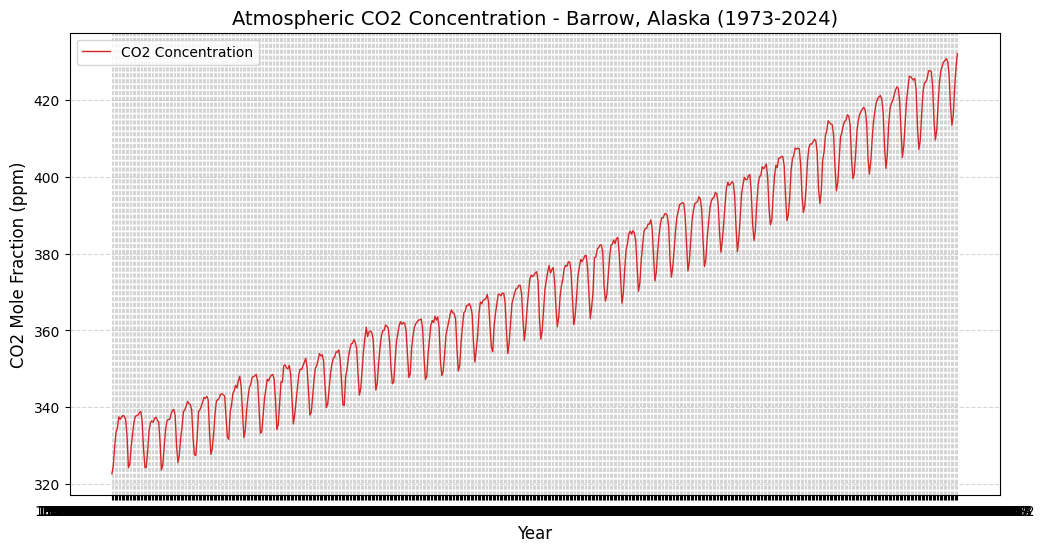

In [29]:
import pandas as pd
import matplotlib.pyplot as plt

# Update this path to where your file is saved
filename = "/content/co2-emissions-barrow.txt"

# 1. Load the Data
# comment='#' skips all the metadata lines automatically
df = pd.read_csv(
    filename,
    sep=r'\s+',
    comment='#',
    header=None,
    engine='python'
)

# 2. Assign the 19 Column Names
df.columns = [
    'site_code', 'year', 'month', 'day', 'hour', 'minute', 'second',
    'datetime', 'time_decimal', 'midpoint_time', 'value', 'value_std_dev',
    'nvalue', 'latitude', 'longitude', 'altitude', 'elevation',
    'intake_height', 'qcflag'
]

# 3. Clean the Data
# Convert to numeric just in case there are stray strings, then filter out -999.99
df['value'] = pd.to_numeric(df['value'], errors='coerce')
df = df[df['value'] > 0]

# 4. Create the Scientific Plot
plt.figure(figsize=(12, 6))
plt.plot(df['time_decimal'], df['value'], color='tab:red', linewidth=1, label='CO2 Concentration')

# Formatting for a scientific report
plt.title("Atmospheric CO2 Concentration - Barrow, Alaska (1973-2024)", fontsize=14)
plt.xlabel("Year", fontsize=12)
plt.ylabel("CO2 Mole Fraction (ppm)", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()

# Display the first few rows of the cleaned data
print("Data successfully loaded. Shape:", df.shape)
print(df[['year', 'month', 'value']].head())

plt.show()

##Problem 2

In this exercise, you will create your own visualization using a dataset of your choice.

The economic time series for Colombia was compiled using historical records from the World Bank and the International Monetary Fund (IMF).

Source: World Bank Open Data - Colombia GDP (Current USD)

Source: IMF World Economic Outlook Database

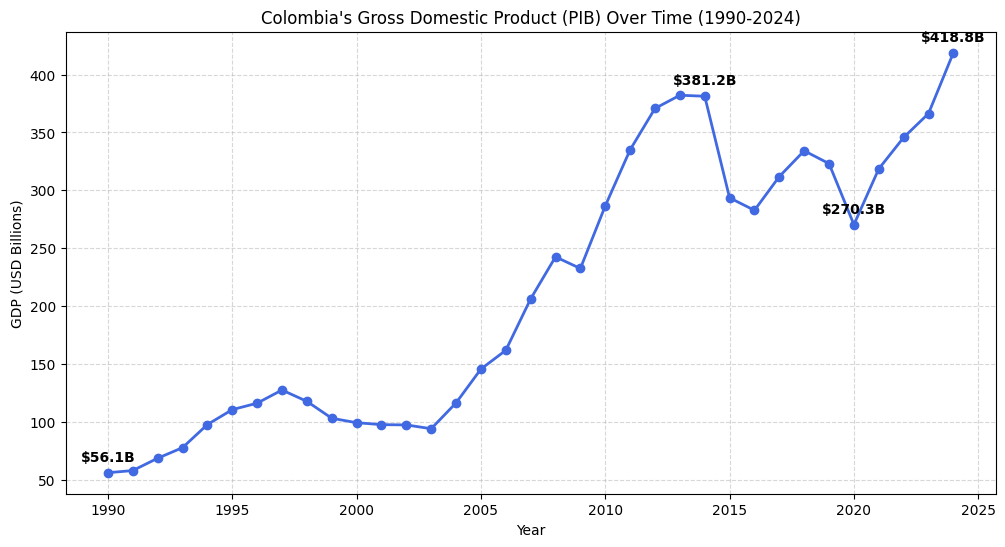

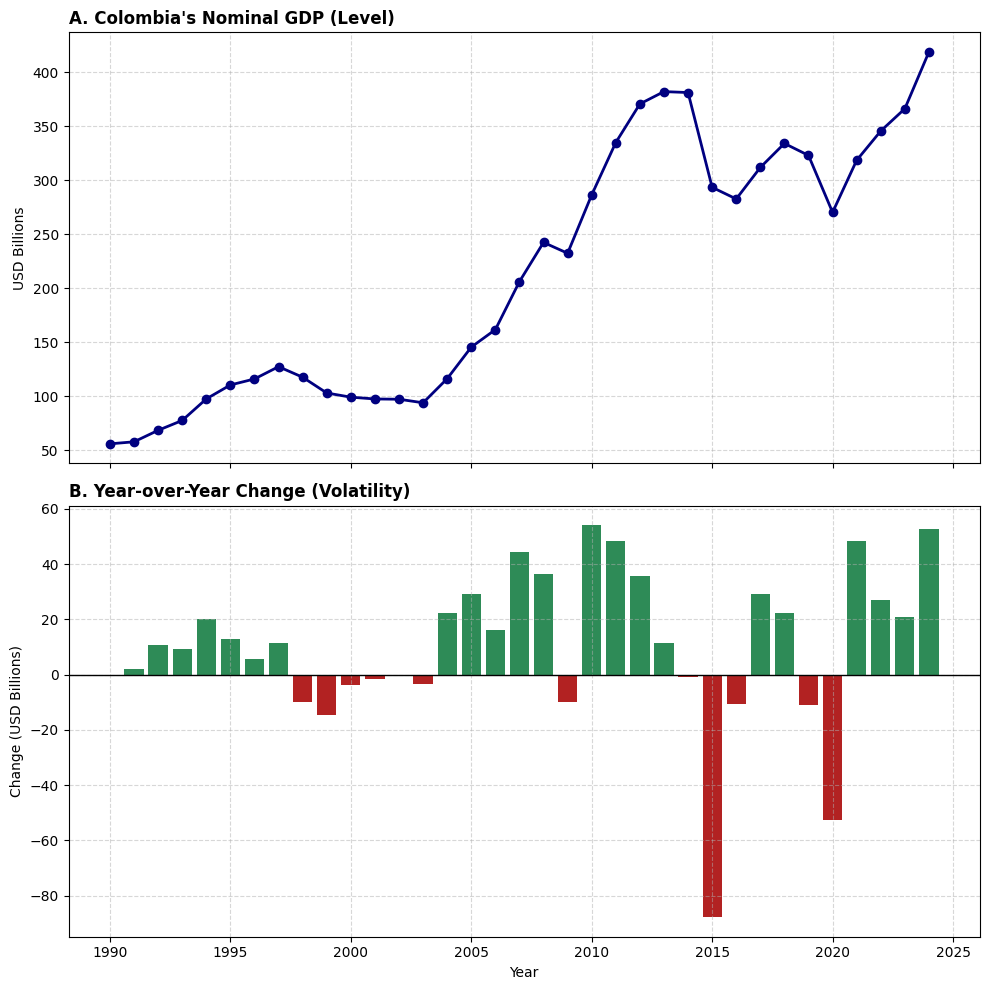

In [34]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the GDP data
df_pib = pd.read_csv("colombia_pib_time_series.csv")

# Create the plot
plt.figure(figsize=(12, 6))
plt.plot(df_pib['Year'], df_pib['GDP_USD_Billions'], marker='o', color='royalblue', linewidth=2)

# Formatting
plt.title("Colombia's Gross Domestic Product (PIB) Over Time (1990-2024)")
plt.xlabel("Year")
plt.ylabel("GDP (USD Billions)")
plt.grid(True, linestyle='--', alpha=0.5)

# Label key points (e.g., 1990, 2014, 2020, 2024)
for year in [1990, 2014, 2020, 2024]:
    val = df_pib.loc[df_pib['Year'] == year, 'GDP_USD_Billions'].values[0]
    plt.text(year, val + 10, f"${val:.1f}B", ha='center', fontweight='bold')

plt.show()

# Calculate Year-over-Year change
df_pib['Annual_Change'] = df_pib['GDP_USD_Billions'].diff()

# Create Figure with 2 Subplots
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 10), sharex=True)

# Subplot A: Absolute GDP
ax1.plot(df_pib['Year'], df_pib['GDP_USD_Billions'], marker='o', color='navy', linewidth=2)
ax1.set_title("A. Colombia's Nominal GDP (Level)", loc='left', fontweight='bold')
ax1.set_ylabel("USD Billions")
ax1.grid(True, linestyle='--', alpha=0.5)

# Subplot B: Annual Change (Volatility)
colors = ['firebrick' if x < 0 else 'seagreen' for x in df_pib['Annual_Change'].fillna(0)]
ax2.bar(df_pib['Year'], df_pib['Annual_Change'], color=colors)
ax2.axhline(0, color='black', linewidth=1)
ax2.set_title("B. Year-over-Year Change (Volatility)", loc='left', fontweight='bold')
ax2.set_ylabel("Change (USD Billions)")
ax2.set_xlabel("Year")
ax2.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()